In [1]:
import pandas as pd
import pickle

# Load the XGBoost model
print("Loading XGBoost model...")
with open('../models//xgb_final.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

# Load the native training and test dataset

print("Loading training and test datasets...")
X_train_native = pd.read_pickle('../data/processed/X_train_native.pkl')
X_test_native = pd.read_pickle('../data/processed/X_test_native.pkl')

# Load enrolled students dataset
print("Loading enrolled students data...")
enrolled_students = pd.read_csv('../data/processed/enrolled_students.csv')

print("\nAll assets loaded correctly:")
print(f"  XGBoost Model Type: {type(xgb_model)}")
print(f"  X_train_native Shape: {X_train_native.shape}")
print(f"  X_test_native Shape: {X_test_native.shape}")
print(f"  enrolled_students Shape: {enrolled_students.shape}")

Loading XGBoost model...
Loading training and test datasets...
Loading enrolled students data...

All assets loaded correctly:
  XGBoost Model Type: <class 'xgboost.sklearn.XGBClassifier'>
  X_train_native Shape: (2904, 30)
  X_test_native Shape: (726, 30)
  enrolled_students Shape: (794, 37)


Aligning Features for Enrolled Students

In [2]:
# Extract the columns names on which the model was trained
expected_features = X_train_native.columns

# Filter the enrolled students dataset to only include those 30 columns
X_enrolled_aligned = enrolled_students[expected_features]

# Ensure the categorical data types match the training set
for col in X_train_native.select_dtypes(include=['category']).columns:
    X_enrolled_aligned[col] = X_enrolled_aligned[col].astype(
        X_train_native[col].dtype
    )

# Ensure the categorical data types match the test set
for col in X_train_native.select_dtypes(include=['category']).columns:
    X_test_native[col] = X_test_native[col].astype(X_train_native[col].dtype)

print(f"Original enrolled_students shape: {enrolled_students.shape}")
print(f"Aligned X_enrolled_aligned shape: {X_enrolled_aligned.shape}")
print(f"Model expected features: {len(expected_features)}")
print(f"X_test_native shape: {X_test_native.shape}")

Original enrolled_students shape: (794, 37)
Aligned X_enrolled_aligned shape: (794, 30)
Model expected features: 30
X_test_native shape: (726, 30)


/var/folders/wm/y1qvdc9j1jl9sqv3jtbt7dvw0000gn/T/ipykernel_61203/3721930526.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_enrolled_aligned[col] = X_enrolled_aligned[col].astype(
/var/folders/wm/y1qvdc9j1jl9sqv3jtbt7dvw0000gn/T/ipykernel_61203/3721930526.py:15: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_test_native[col] = X_test_native[col].astype(X_train_native[col].dtype)


Initialising SHAP

In [3]:
import shap

# Initialise JavaScript viusalisation this is required for interactive SHAP plots later
shap.initjs()

# Create tree explainer uisng the loaded XGBoost model
print("Building SHAP TreeExplainer...")
explainer = shap.TreeExplainer(xgb_model)

# Calculate the SHAP values on native test set
print("Calculating SHAP values")
shap_values = explainer.shap_values(X_test_native)

# Print shapes to confirm generation
print(f"Original X_test_native shape: {X_test_native.shape}")

# Handle SHAP output safely
if isinstance(shap_values, list):
    print(f"SHAP values shape (Dropout class): {shap_values[1].shape}")
else:
    print(f"SHAP values shape: {shap_values.shape}")



Building SHAP TreeExplainer...
Calculating SHAP values
Original X_test_native shape: (726, 30)
SHAP values shape: (726, 30)


Global Feature Importance

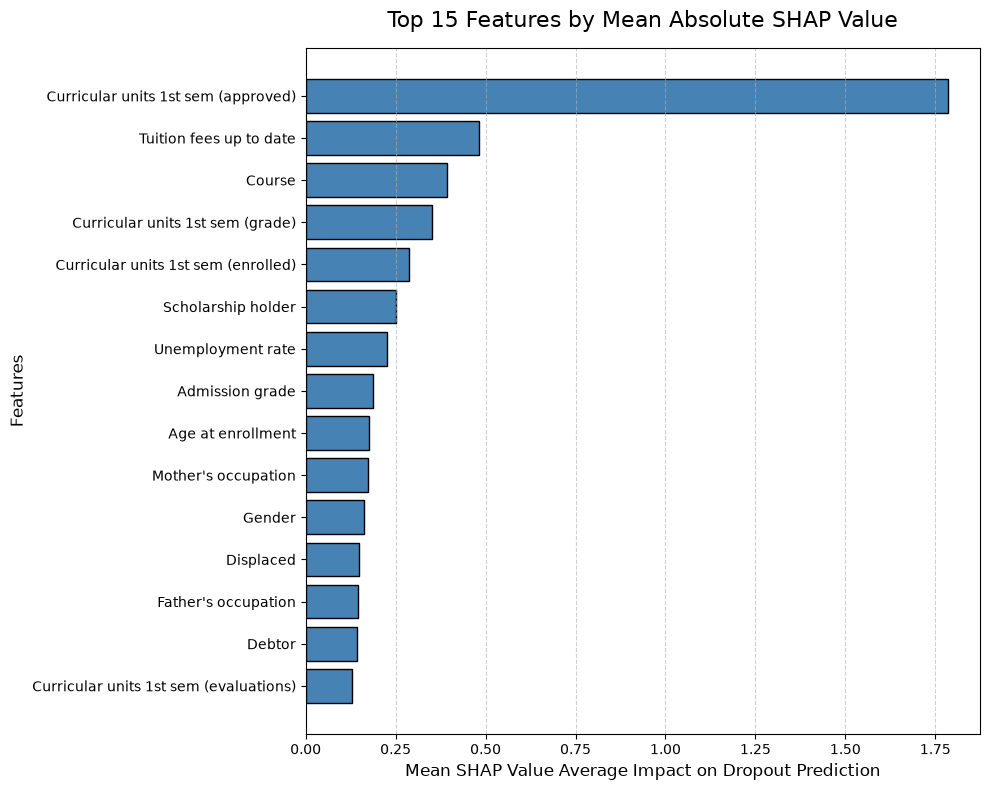

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extract SHAP values for the dropout class
if isinstance(shap_values, list):
    shap_vals_dropout = shap_values[1]
else:
    shap_vals_dropout = shap_values

# Calculate the Mean Absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_vals_dropout).mean(axis=0)

# Create a pandas DataFrame to pair features with their scores and sort them
feature_importance_df = pd.DataFrame({
    'Feature': X_test_native.columns,
    'Mean_Abs_SHAP': mean_abs_shap
})

# Sort ascending so the largest value ends up at top of the plot
feature_importance_df = feature_importance_df.sort_values(by='Mean_Abs_SHAP', ascending=True)

# Select top 15 features to keep the chart clean
top_features_df = feature_importance_df.tail(15)

# Plot the bar chart
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_features_df['Feature'], top_features_df['Mean_Abs_SHAP'], 
               color='steelblue', edgecolor='black')

# Apply titles
ax.set_title('Top 15 Features by Mean Absolute SHAP Value', fontsize=16, pad=15)
ax.set_xlabel('Mean SHAP Value Average Impact on Dropout Prediction', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../outputs/figures/shap_mean_absolute_importance.png', dpi=300, bbox_inches='tight')
plt.show()

SHAP Beeswarm plot

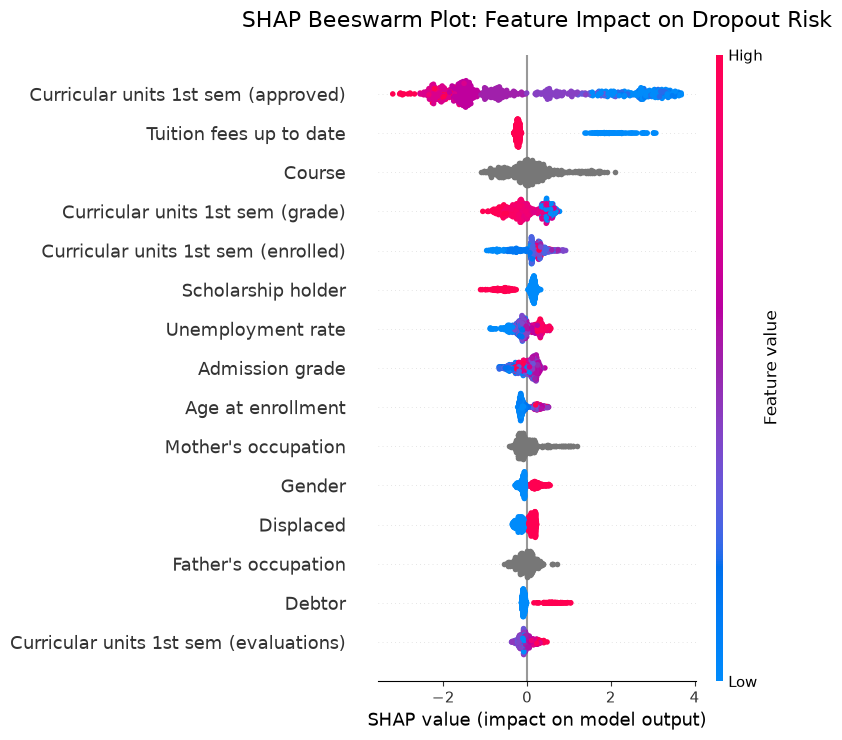

In [10]:
import shap
import matplotlib.pyplot as plt

# Create plot
plt.figure(figsize=(10, 6))

# SHAP beeswarm plot
shap.summary_plot(
    shap_vals_dropout, # Only looking for dropout risk
    X_test_native,
    plot_type='dot', 
    max_display=15, # Only top 15 features
    show=False # Prevent SHAP from immediately rendering the plot
)
# Apply title
plt.title('SHAP Beeswarm Plot: Feature Impact on Dropout Risk', fontsize=16, pad=20)
plt.tight_layout()

plt.savefig('../outputs/figures/shap_beeswarm_plot.png', dpi=300, bbox_inches='tight')

plt.show()

Generating Real World Risk Assessments

In [11]:
import numpy as np
import pandas as pd

# Generate probability for each enrolled students
print("Calculating dropout probabilities...")
dropout_probs = xgb_model.predict_proba(X_enrolled_aligned)[:, 1] # this is used to slice to Dropout column only

# Add probability scores back to enrolled students dataframe we will also use a copy of the orignal dataframe to keep semester 2 data and avoid warnings
risk_df = enrolled_students.copy()
risk_df['Dropout_Probability'] = dropout_probs

# Classify into risk categories using Numpy highly optimised select function
conditions = [
    risk_df['Dropout_Probability'] > 0.70,
    (risk_df['Dropout_Probability'] >= 0.40) & (risk_df['Dropout_Probability'] <= 0.70),
    risk_df['Dropout_Probability'] < 0.40
]
choices = ['High Risk', 'Medium Risk', 'Low Risk']
risk_df['Risk_Category'] = np.select(conditions, choices, default='Unknown')

# Show top 10 High risk studnets ranked by dropout probability
print("\n--- Top 10 Highest Risk Students ---")
risk_df_sorted = risk_df.sort_values(by='Dropout_Probability', ascending=False)

# We select a few key columns to display cleanly so it doesn't overwhelm the screen
display_cols = ['Dropout_Probability', 'Risk_Category', 'Course', 'Age at enrollment', 'Tuition fees up to date']
display(risk_df_sorted[display_cols].head(10))

# Print risk category summary
print("\n--- Risk Category Summary ---")
# Reindexing ensures the categories print in a logical severity order rather than just alphabetical
summary_counts = risk_df['Risk_Category'].value_counts().reindex(['High Risk', 'Medium Risk', 'Low Risk'])
print(summary_counts.to_string())

Calculating dropout probabilities...

--- Top 10 Highest Risk Students ---


,Dropout_Probability,Risk_Category,Course,Age at enrollment,Tuition fees up to date
553,0.999281,High Risk,9119,27,0
156,0.999091,High Risk,9119,18,0
390,0.997203,High Risk,9085,25,0
414,0.995561,High Risk,9119,24,1
484,0.994245,High Risk,9119,20,1
29,0.994181,High Risk,9147,22,0
170,0.993784,High Risk,9119,18,0
332,0.993628,High Risk,9119,34,1
410,0.993560,High Risk,9119,19,1
688,0.993163,High Risk,9119,18,1



--- Risk Category Summary ---
Risk_Category
High Risk      309
Medium Risk    146
Low Risk       339


Mapping Categorical Codes to Readable Names

In [14]:
# Define the course mapping dictionary
course_map = {
    33: 'Biofuel Production',
    171: 'Animation & Multimedia',
    8014: 'Social Service (Evening)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising & Marketing',
    9773: 'Journalism',
    9853: 'Basic Education',
    9991: 'Management (Evening)'
}

# Map the numeric codes to readable strings
risk_df_sorted['Course_Name'] = risk_df_sorted['Course'].map(course_map)

# Update the display columns to show 'Course_Name' instead of the raw 'Course' integer
display_cols_readable = [
    'Dropout_Probability', 
    'Risk_Category', 
    'Course_Name', 
    'Age at enrollment', 
    'Tuition fees up to date'
]

print("\n--- Top 10 Highest Risk Students ---")
display(risk_df_sorted[display_cols_readable].head(10))


--- Top 10 Highest Risk Students ---


,Dropout_Probability,Risk_Category,Course_Name,Age at enrollment,Tuition fees up to date
553,0.999281,High Risk,Informatics Engineering,27,0
156,0.999091,High Risk,Informatics Engineering,18,0
390,0.997203,High Risk,Veterinary Nursing,25,0
414,0.995561,High Risk,Informatics Engineering,24,1
484,0.994245,High Risk,Informatics Engineering,20,1
29,0.994181,High Risk,Management,22,0
170,0.993784,High Risk,Informatics Engineering,18,0
332,0.993628,High Risk,Informatics Engineering,34,1
410,0.993560,High Risk,Informatics Engineering,19,1
688,0.993163,High Risk,Informatics Engineering,18,1


Local SHAP Waterfall Plot

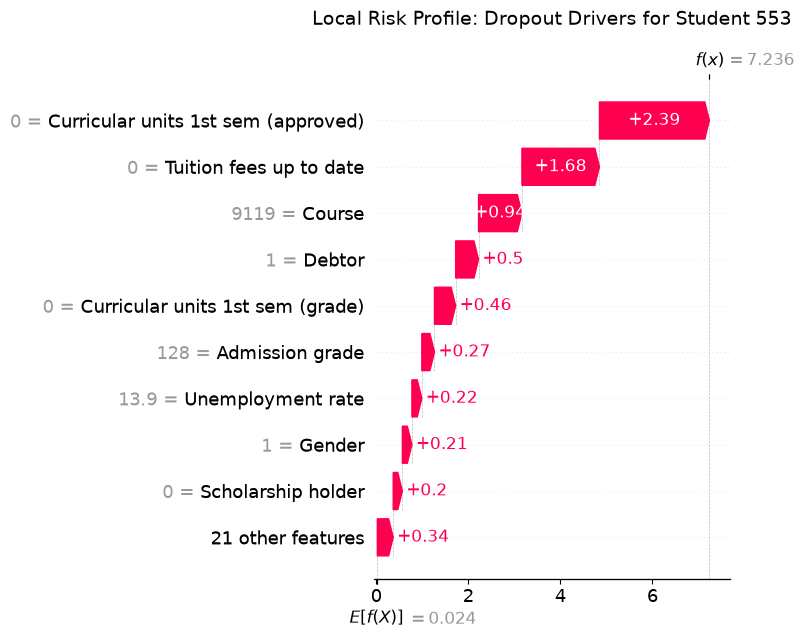

In [17]:
import shap
import matplotlib.pyplot as plt

# Define the studet index
student_idx = 553

# Extract student features from the aligned dataset
student_data = X_enrolled_aligned.loc[[student_idx]]

# Generate the SHAP Explanation
local_explanation = explainer(student_data)

# Extract explanation for dropout class
if len(local_explanation.shape) == 3:
    exp_dropout = local_explanation[0, :, 1]
else:
    exp_dropout = local_explanation[0]

# Plot waterfall chart
plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp_dropout, max_display=10, show=False)

# Apply titles
plt.title(f"Local Risk Profile: Dropout Drivers for Student {student_idx}", fontsize=14, pad=20)
plt.tight_layout()

plt.savefig(f'../outputs/figures/shap_waterfall_student.png', dpi=300, bbox_inches='tight')
plt.show()


In [20]:
output_csv_path = '../outputs/enrolled_students_risk_registry.csv'

print("Exporting risk registry")
risk_df_sorted.to_csv(output_csv_path, index=False)

# Final confirmation 
print(f"Risk scores for all {len(risk_df_sorted)} enrolled students have been saved")

Exporting risk registry
Risk scores for all 794 enrolled students have been saved
